# 5.6 — PCA de la curva: nivel, pendiente y curvatura

Los notebooks anteriores de M5 construyeron la curva (5.2-5.4) y midieron su sensibilidad nodo por nodo (5.5): 11 key-rate durations, una por vértice. En la práctica nadie cubre 11 riesgos independientes — la curva no se mueve vértice por vértice, se mueve en unos pocos **modos comunes** que explican casi toda la variación histórica de las tasas. Este notebook extrae esos modos vía **componentes principales (PCA)** sobre una historia de cambios de la curva, muestra que los tres primeros tienen la forma canónica de **nivel, pendiente y curvatura** — un resultado empírico muy replicado en mercados de tasas (Litterman & Scheinkman, 1991) — y traduce las key-rate durations de 5.5 a un puñado de sensibilidades por factor, la base de la cobertura y de los escenarios de estrés coherentes con la historia.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.market import nelson_siegel_zero, par_swap_rate
from qflib.curves import DiscountCurve
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

## 1. Por qué PCA sobre *cambios*, no sobre niveles

Sea $z_t(\tau)$ la tasa zero a plazo $\tau$ observada en el día $t$. Si se hiciera PCA directamente sobre los **niveles** $z_t(\tau)$, el primer componente principal capturaría, casi por construcción, el nivel medio de la curva a través del tiempo — la serie $z_t(\tau)$ no es estacionaria (las tasas caminan con memoria larga, se parecen mucho de un día al siguiente), así que su matriz de covarianza está dominada por esa tendencia común y el PCA no dice nada interesante sobre la *dinámica* de la curva. La cantidad estacionaria y económicamente relevante es el **cambio diario**
$$
\Delta z_t(\tau) = z_t(\tau) - z_{t-1}(\tau),
$$
que sí tiene (aproximadamente) media y covarianza estables en el tiempo. Es sobre estos cambios que se hace PCA.

Con $n$ vértices $\tau_1,\dots,\tau_n$ y $T$ observaciones diarias, se arma la matriz de cambios $X\in\mathbb{R}^{T\times n}$ (fila $t$ = $\Delta z_t(\tau_1),\dots,\Delta z_t(\tau_n)$, ya centrada por columna) y su matriz de covarianza muestral
$$
\Sigma = \frac{1}{T-1}X^\top X \in \mathbb{R}^{n\times n}.
$$
$\Sigma$ es simétrica y semidefinida positiva, así que admite descomposición espectral
$$
\Sigma = V\Lambda V^\top,\qquad V^\top V = I,\qquad \Lambda=\mathrm{diag}(\lambda_1\geq\lambda_2\geq\cdots\geq\lambda_n\geq 0).
$$
Cada columna $v_k$ de $V$ (un **loading** por vértice) es el $k$-ésimo **componente principal**; $\lambda_k$ es la varianza de los cambios de la curva explicada por ese componente, y $\mathrm{tr}(\Sigma)=\sum_i \Sigma_{ii}=\sum_k \lambda_k$ es la varianza total. La **proporción de varianza explicada** por los primeros $k$ componentes es $\sum_{j\leq k}\lambda_j / \sum_j \lambda_j$.

El cambio del día $t$ se puede escribir exactamente en la base de componentes,
$$
\Delta z_t = \sum_{k=1}^n c_{t,k}\, v_k, \qquad c_{t,k} = v_k^\top \Delta z_t \ \ (\text{score del componente } k),
$$
y truncar la suma a los primeros $m<n$ componentes da una **reconstrucción de rango reducido** — la idea detrás de comprimir el riesgo de 11 vértices a 3 factores.

## 2. Datos: una historia sintética de curvas Nelson-Siegel

No hay una fuente de tasas históricas en este repo, así que se genera una historia sintética coherente: se simulan los tres parámetros de Nelson-Siegel — nivel $\beta_0$, pendiente $\beta_1$ y curvatura $\beta_2$ — como paseos aleatorios correlacionados (mismo espíritu que 01.4/01.5: incrementos gaussianos), se reconstruye la curva zero completa cada día con `nelson_siegel_zero`, y se le añade un ruido idiosincrático pequeño por vértice (error de medición / iliquidez de un tenor puntual, no explicado por los tres factores macro). Esto es suficiente para el punto pedagógico: lo que importa no es replicar tasas reales sino que la *estructura de covarianza* generada tenga modos dominantes y ruido residual, exactamente como en datos de mercado — y así verificar que el PCA los separa sin que la forma canónica se haya impuesto a mano en los datos.

In [2]:
vertices = np.array([1/12, 3/12, 6/12, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0])
n_vertices = len(vertices)
n_days = 2000

# Parametros NS iniciales (curva "normal" con pendiente positiva y ligera joroba)
beta0_0, beta1_0, beta2_0, tau_ns = 0.045, -0.015, 0.008, 2.0

# Paseos aleatorios correlacionados para (beta0, beta1, beta2): nivel es el mas
# persistente y de menor volatilidad diaria, la curvatura el mas ruidoso.
vol_beta = np.array([0.0006, 0.0009, 0.0014])   # vol diaria de cada parametro NS
corr_beta = np.array([[1.0, -0.3, 0.1],
                       [-0.3, 1.0, -0.2],
                       [0.1, -0.2, 1.0]])
L_beta = np.linalg.cholesky(corr_beta)

beta_shocks = rng.standard_normal((n_days, 3)) @ L_beta.T * vol_beta
betas = beta_shocks.cumsum(axis=0) + np.array([beta0_0, beta1_0, beta2_0])

# Curva zero cada dia + ruido idiosincratico por vertice (iliquidez / medicion)
idio_vol = 0.0001
zero_curves = np.array([
    nelson_siegel_zero(vertices, beta0=b0, beta1=b1, beta2=b2, tau=tau_ns)
    for b0, b1, b2 in betas
])
zero_curves += idio_vol * rng.standard_normal(zero_curves.shape)

print(f"Historia sintetica: {n_days} dias x {n_vertices} vertices")
print(f"Nivel medio (beta0): {betas[:,0].mean():.4%}, rango zero 10Y: "
      f"[{zero_curves[:,8].min():.4%}, {zero_curves[:,8].max():.4%}]")

Historia sintetica: 2000 dias x 11 vertices
Nivel medio (beta0): 4.2856%, rango zero 10Y: [0.7032%, 5.0705%]


Los cambios diarios de la curva son la diferencia de primer orden de `zero_curves`; se centran por vértice (media cero por columna) antes de construir la matriz de covarianza — el PCA se hace sobre la variación, no sobre el nivel medio residual de la muestra.

In [3]:
dz = np.diff(zero_curves, axis=0)          # (n_days-1, n_vertices), cambios diarios
dz_centered = dz - dz.mean(axis=0, keepdims=True)
n_obs = dz_centered.shape[0]

cov = (dz_centered.T @ dz_centered) / (n_obs - 1)
print(f"Cambios diarios: {n_obs} observaciones. Cov shape = {cov.shape}")
print(f"Vol diaria del cambio en 10Y: {np.sqrt(cov[8,8]):.6f} (~{np.sqrt(cov[8,8])*1e4:.2f} bp)")

Cambios diarios: 1999 observaciones. Cov shape = (11, 11)
Vol diaria del cambio en 10Y: 0.000650 (~6.50 bp)


## 3. Descomposición espectral: eigenvalores y eigenvectores

`np.linalg.eigh` está hecho para matrices simétricas y devuelve los eigenvalores en orden **creciente** — se invierten para tener $\lambda_1\geq\lambda_2\geq\cdots$ y se reordenan las columnas de eigenvectores en consecuencia. El signo de cada eigenvector es arbitrario ($v$ y $-v$ son ambos soluciones válidas de $\Sigma v=\lambda v$), así que se fija una convención: el signo de cada columna se elige para que la suma de sus loadings sea positiva. Esto no cambia ningún resultado económico (una rotación de signo no altera la varianza explicada ni la reconstrucción, solo si el score correspondiente se llama "+1 shock" o "-1 shock"), pero hace reproducibles las comparaciones de forma que vienen después.

In [4]:
eigvals_raw, eigvecs_raw = np.linalg.eigh(cov)   # ascendente
order = np.argsort(eigvals_raw)[::-1]
eigvals = eigvals_raw[order]
eigvecs = eigvecs_raw[:, order]

# Convencion de signo: suma de loadings de cada componente positiva
signs = np.sign(eigvecs.sum(axis=0))
signs[signs == 0] = 1.0
eigvecs = eigvecs * signs

var_explained = eigvals / eigvals.sum()
var_cum = np.cumsum(var_explained)

for k in range(4):
    print(f"PC{k+1}: lambda = {eigvals[k]:.3e}  var explicada = {var_explained[k]:.2%}  acumulada = {var_cum[k]:.2%}")

PC1: lambda = 5.190e-06  var explicada = 80.76%  acumulada = 80.76%
PC2: lambda = 9.217e-07  var explicada = 14.34%  acumulada = 95.10%
PC3: lambda = 1.541e-07  var explicada = 2.40%  acumulada = 97.50%
PC4: lambda = 2.266e-08  var explicada = 0.35%  acumulada = 97.85%


### Demo 1 — Los tres modos: nivel, pendiente y curvatura

Se grafican los primeros tres eigenvectores (loadings) contra el plazo, en escala log para separar el tramo corto. La forma que debería emerger — sin que se haya impuesto en ningún lado del código anterior, es puramente el resultado de la estructura de covarianza generada en la Sección 2 — es la triada clásica de Litterman-Scheinkman: PC1 casi plano y del mismo signo en todos los vértices (un desplazamiento paralelo, "nivel"), PC2 monótono con un cambio de signo entre el tramo corto y el largo ("pendiente": empina o aplana la curva), y PC3 con forma de U o joroba, positivo en los extremos y negativo (o viceversa) en el medio ("curvatura").

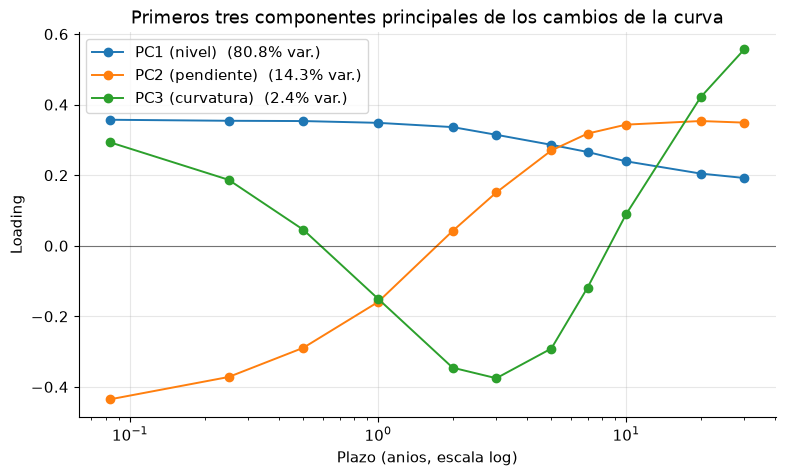

In [5]:
fig, ax = plt.subplots()
labels = ["PC1 (nivel)", "PC2 (pendiente)", "PC3 (curvatura)"]
for k in range(3):
    ax.plot(vertices, eigvecs[:, k], marker="o", label=f"{labels[k]}  ({var_explained[k]:.1%} var.)")
ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xscale("log")
ax.set_xlabel("Plazo (anios, escala log)")
ax.set_ylabel("Loading")
ax.set_title("Primeros tres componentes principales de los cambios de la curva")
ax.legend()
plt.show()

### Demo 2 — Varianza explicada por componente

La utilidad práctica del PCA depende de que unos pocos modos concentren casi toda la varianza — si hicieran falta 8 de 11 componentes para llegar al 95% no habría compresión de riesgo que ganar. Se grafica la varianza explicada por cada componente individual y la acumulada: el patrón típico en curvas de tasas es PC1 solo ya en 80-90%, y los tres primeros juntos por encima de 95%.

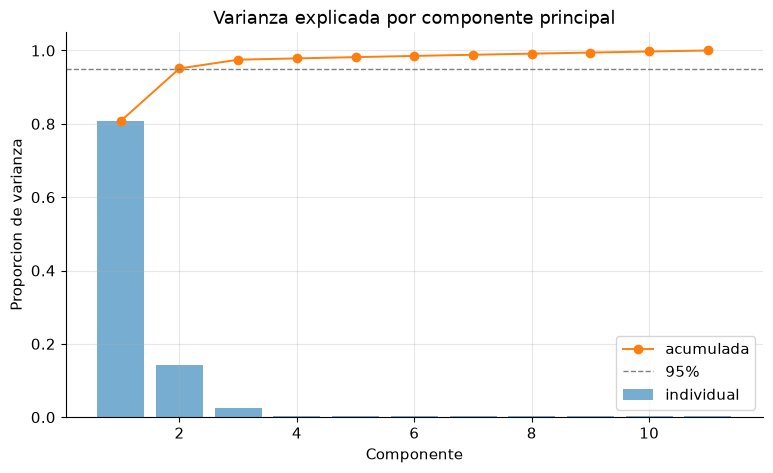

PC1: 80.76% | PC1-3 acumulado: 97.50%


In [6]:
fig, ax = plt.subplots()
idx = np.arange(1, n_vertices + 1)
ax.bar(idx, var_explained, alpha=0.6, label="individual")
ax.plot(idx, var_cum, marker="o", color="C1", label="acumulada")
ax.axhline(0.95, color="gray", linestyle="--", linewidth=1.0, label="95%")
ax.set_xlabel("Componente")
ax.set_ylabel("Proporcion de varianza")
ax.set_title("Varianza explicada por componente principal")
ax.legend()
plt.show()

print(f"PC1: {var_explained[0]:.2%} | PC1-3 acumulado: {var_cum[2]:.2%}")

### Demo 3 — Reconstrucción con $k$ componentes y error residual

Cada día de cambios se puede proyectar sobre los primeros $k$ eigenvectores y reconstruir una aproximación $\widehat{\Delta z}_t^{(k)} = \sum_{j\le k} c_{t,j}\,v_j$. El error cuadrático medio de esa reconstrucción, promediado sobre todos los días y vértices, debe caer monótonamente con $k$ — cada componente adicional solo puede explicar más varianza, nunca menos — y llegar a (esencialmente) cero cuando $k=n$, porque entonces la base de eigenvectores es completa y la reconstrucción es exacta.

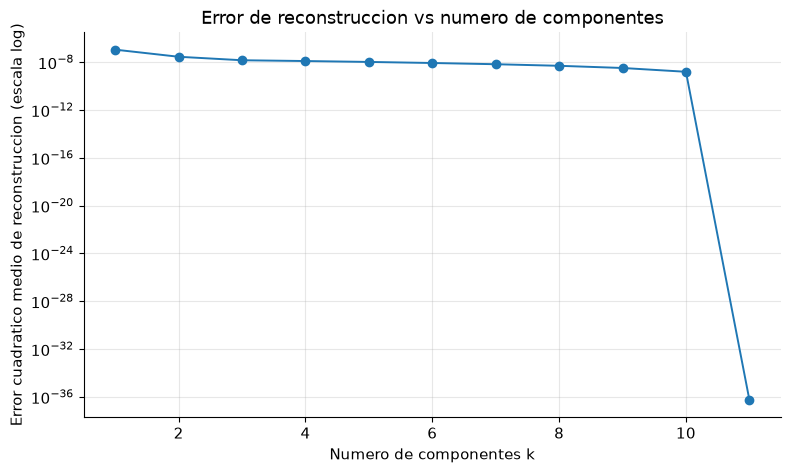

k= 1: MSE reconstruccion = 1.124e-07
k= 2: MSE reconstruccion = 2.862e-08
k= 3: MSE reconstruccion = 1.462e-08
k=11: MSE reconstruccion = 5.878e-37


In [7]:
scores_all = dz_centered @ eigvecs   # (n_obs, n_vertices), c_{t,k} = v_k . dz_t

recon_errors = []
for k in range(1, n_vertices + 1):
    recon_k = scores_all[:, :k] @ eigvecs[:, :k].T
    mse_k = np.mean((dz_centered - recon_k) ** 2)
    recon_errors.append(mse_k)
recon_errors = np.array(recon_errors)

fig, ax = plt.subplots()
ax.plot(np.arange(1, n_vertices + 1), recon_errors, marker="o")
ax.set_yscale("log")
ax.set_xlabel("Numero de componentes k")
ax.set_ylabel("Error cuadratico medio de reconstruccion (escala log)")
ax.set_title("Error de reconstruccion vs numero de componentes")
plt.show()

for k in (1, 2, 3, n_vertices):
    print(f"k={k:2d}: MSE reconstruccion = {recon_errors[k-1]:.3e}")

### Demo 4 — De key-rate durations (5.5) a sensibilidades por factor

En 5.5 el riesgo de un swap se descompuso en 11 key-rate durations $\mathrm{KRD}_i$, una por vértice: el cambio de valor bajo un movimiento arbitrario de la curva es $\Delta V \approx \sum_i \mathrm{KRD}_i \cdot \Delta z(\tau_i)$ (en unidades de bp de cada vértice). Si el movimiento se restringe a los modos de PCA, $\Delta z \approx \sum_k c_k v_k$, entonces
$$
\Delta V \approx \sum_i \mathrm{KRD}_i \sum_k c_k v_k(\tau_i) = \sum_k c_k \underbrace{\left(\sum_i \mathrm{KRD}_i\, v_k(\tau_i)\right)}_{\textstyle \mathrm{FKRD}_k} ,
$$
es decir, la **sensibilidad al factor $k$** ($\mathrm{FKRD}_k$) es simplemente el KRD-vector proyectado sobre el eigenvector $v_k$ — el mismo producto punto que da los scores de la Sección 3, aplicado al vector de riesgo en vez de a un día de datos. Con esto, cubrir un libro ya no exige 11 posiciones de cobertura (una por vértice) sino, en la práctica, 2 o 3 (nivel y pendiente casi siempre bastan) porque son los factores que de verdad se mueven de forma independiente en el mercado.

Se reutiliza el swap 10Y de 5.5 (KRD via bump-and-reprice de un nodo a la vez, con la misma curva bootstrapeada de vértices anuales 1..10Y para no arrastrar el step de 1M/3M/6M) y se traduce su vector de KRD a $\mathrm{FKRD}_1,\mathrm{FKRD}_2,\mathrm{FKRD}_3$ usando los eigenvectores restringidos a esos mismos vértices (renormalizados para seguir siendo unitarios en el subespacio de 10 nodos). Después se compara el P&L bajo un shock de **nivel puro** ($c_1=1\sigma_1$, todos los demás scores en cero) contra un shock de **pendiente pura** ($c_2=1\sigma_2$): el swap receptor de fijo tiene $\mathrm{KRD}$ positivo y creciente con el plazo, así que un shock de nivel (todos los loadings positivos y similares) mueve el valor en una sola dirección grande, mientras que un shock de pendiente (loadings de signo opuesto en el tramo corto y largo) se cancela parcialmente porque los KRD de tramos opuestos entran con signos opuestos en la suma.

In [8]:
def swap_pv(curve_df_fn, K, payment_times):
    """PV of a receive-fixed/pay-float swap, single-curve (matches 5.5 sign convention)."""
    t = np.asarray(payment_times, dtype=float)
    d = curve_df_fn(t)
    tau = np.diff(np.concatenate([[0.0], t]))
    return K * np.sum(tau * d) - (1.0 - d[-1])


def bump_single_node(times, dfs, node_idx, bp):
    z = -np.log(dfs) / times
    z_bumped = z.copy()
    z_bumped[node_idx] += bp * 1e-4
    return DiscountCurve(times, np.exp(-z_bumped * times))


# Curva de 10 nodos anuales 1..10Y (malla propia, mas fina que los vertices de PCA)
times_10 = np.arange(1, 11, dtype=float)
dfs_10 = np.exp(-nelson_siegel_zero(times_10, beta0=beta0_0, beta1=beta1_0, beta2=beta2_0, tau=tau_ns) * times_10)
curve_10 = DiscountCurve(times_10, dfs_10)
K10 = par_swap_rate(curve_10.df, times_10)

krd_bp = 1.0
krd_10 = np.zeros(10)
for i in range(10):
    c_up = bump_single_node(times_10, dfs_10, i, krd_bp)
    c_dn = bump_single_node(times_10, dfs_10, i, -krd_bp)
    krd_10[i] = (swap_pv(c_up.df, K10, times_10) - swap_pv(c_dn.df, K10, times_10)) / (2 * krd_bp)

print("KRD del swap 10Y (por bp, vertices 1..10Y):")
print(np.array2string(krd_10, precision=6))

KRD del swap 10Y (por bp, vertices 1..10Y):
[-4.268518e-06 -8.197169e-06 -1.177230e-05 -1.500880e-05 -1.793005e-05
 -2.056022e-05 -2.292171e-05 -2.503471e-05 -2.691746e-05 -6.754920e-04]


Los eigenvectores de la Sección 3 viven en la malla de 11 vértices (1M...30Y); para proyectar el KRD del swap (que vive en la malla anual 1..10Y) hace falta la misma restricción de vértices e interpolar los loadings de PC1-3 sobre la malla anual 1..10Y, y renormalizar cada uno a norma 1 en ese subespacio de 10 coordenadas (el eigenvector completo ya no es unitario si se le quitan filas). Con eso, $\mathrm{FKRD}_k$ es un solo producto punto.

In [9]:
from numpy import interp

pc_on_10 = np.zeros((10, 3))
for k in range(3):
    pc_on_10[:, k] = interp(times_10, vertices, eigvecs[:, k])
    pc_on_10[:, k] /= np.linalg.norm(pc_on_10[:, k])   # renormalizar en el subespacio de 10 nodos

fkrd = krd_10 @ pc_on_10   # (3,) -- FKRD_1, FKRD_2, FKRD_3
for k in range(3):
    print(f"FKRD_{k+1} ({labels[k]}): {fkrd[k]:.6f}")

# Shock de nivel puro vs pendiente pura, tamano = 1 desviacion estandar del score historico
sigma_scores = scores_all.std(axis=0)
pnl_level = fkrd[0] * (sigma_scores[0] * 1e4)     # score en tasa -> bp
pnl_slope = fkrd[1] * (sigma_scores[1] * 1e4)
print(f"\nP&L bajo shock de 1 sigma de NIVEL   : {pnl_level:+.6f}")
print(f"P&L bajo shock de 1 sigma de PENDIENTE: {pnl_slope:+.6f}")
print(f"|P&L nivel| / |P&L pendiente| = {abs(pnl_level)/abs(pnl_slope):.2f}x")

FKRD_1 (PC1 (nivel)): -0.000223
FKRD_2 (PC2 (pendiente)): -0.000327
FKRD_3 (PC3 (curvatura)): -0.000046

P&L bajo shock de 1 sigma de NIVEL   : -0.005082
P&L bajo shock de 1 sigma de PENDIENTE: -0.003138
|P&L nivel| / |P&L pendiente| = 1.62x


### Demo 5 — Escenarios de estrés coherentes con la historia

Mover un solo vértice ±1bp (como en la KRD de 5.5) es útil para atribuir riesgo, pero como escenario de estrés es una curva que casi nunca ocurre en la práctica: la covarianza histórica dice que los vértices se mueven juntos, no aislados. Un escenario **coherente con la historia** es, en cambio, un shock de $\pm 1$ desviación estándar sobre un componente principal, reconstruido de vuelta a cambios por vértice vía $\Delta z = c_k \, v_k$ con $c_k=\pm\sigma_k$ — la curva resultante tiene la forma exacta del modo (plana, o con pendiente, o con joroba) y una magnitud consistente con lo que de verdad se observó en la muestra sintética.

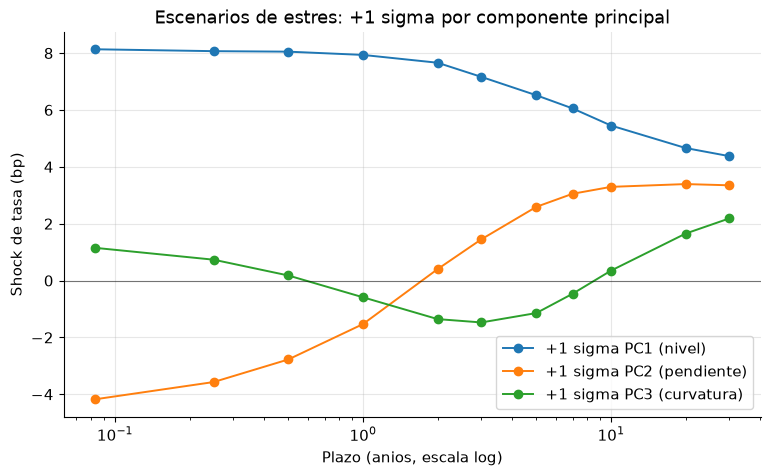

sigma_1 (PC1 (nivel)): 22.777 bp
sigma_2 (PC2 (pendiente)): 9.598 bp
sigma_3 (PC3 (curvatura)): 3.925 bp


In [10]:
fig, ax = plt.subplots()
for k in range(3):
    shock_up = sigma_scores[k] * eigvecs[:, k] * 1e4     # bp por vertice
    ax.plot(vertices, shock_up, marker="o", label=f"+1 sigma {labels[k]}")
ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xscale("log")
ax.set_xlabel("Plazo (anios, escala log)")
ax.set_ylabel("Shock de tasa (bp)")
ax.set_title("Escenarios de estres: +1 sigma por componente principal")
ax.legend()
plt.show()

for k in range(3):
    print(f"sigma_{k+1} ({labels[k]}): {sigma_scores[k]*1e4:.3f} bp")

## 4. Validación

Se verifican, en orden: (1) ortonormalidad de los eigenvectores (matriz de Gram = identidad); (2) eigenvalores no negativos y en orden decreciente; (3) $\sum_k\lambda_k = \mathrm{tr}(\Sigma)$ como identidad exacta (no una aproximación numérica salvo por precisión de máquina); (4) reconstrucción con **todos** los componentes recupera los datos originales a precisión de máquina; (5) los tres primeros componentes explican más del 90% de la varianza; (6) la forma de los modos por conteo de cambios de signo (robusto al ruido de muestreo, a diferencia de comparar valores exactos); (7) cruce entre la implementación manual vía `eigh` sobre la covarianza y `np.linalg.svd` sobre los datos centrados.

In [11]:
# 1. Ortonormalidad: Gram = I
gram = eigvecs.T @ eigvecs
assert np.allclose(gram, np.eye(n_vertices), atol=1e-10), "eigenvectores no ortonormales"

# 2. Eigenvalores no negativos y decrecientes
assert np.all(eigvals >= -1e-12), "eigenvalor negativo"
assert np.all(np.diff(eigvals) <= 1e-12), "eigenvalores no estan en orden decreciente"

# 3. Suma de eigenvalores = traza de la covarianza (identidad exacta)
trace_cov = np.trace(cov)
assert abs(eigvals.sum() - trace_cov) < 1e-10 * max(1.0, abs(trace_cov)), "suma(lambda) != tr(Sigma)"

# 4. Reconstruccion completa (k=n) recupera los datos a precision de maquina
recon_full = scores_all @ eigvecs.T
assert np.allclose(recon_full, dz_centered, atol=1e-8), "reconstruccion completa no exacta"
assert recon_errors[-1] < 1e-16, "MSE de reconstruccion completa deberia ser ~0"

# 5. Los 3 primeros componentes explican > 90% de la varianza
assert var_cum[2] > 0.90, f"PC1-3 solo explican {var_cum[2]:.2%}, se esperaba >90%"

# 6. Forma de los modos por conteo de cambios de signo (ya normalizados: suma PC1 > 0)
def sign_changes(v, tol=1e-12):
    s = np.sign(v)
    s[np.abs(v) < tol] = 0
    s_nz = s[s != 0]
    return int(np.sum(s_nz[1:] != s_nz[:-1]))

sc1, sc2, sc3 = sign_changes(eigvecs[:, 0]), sign_changes(eigvecs[:, 1]), sign_changes(eigvecs[:, 2])
print(f"Cambios de signo: PC1={sc1}, PC2={sc2}, PC3={sc3}")
assert sc1 == 0, f"PC1 (nivel) deberia tener 0 cambios de signo, tiene {sc1}"
assert sc2 == 1, f"PC2 (pendiente) deberia tener 1 cambio de signo, tiene {sc2}"
assert sc3 == 2, f"PC3 (curvatura) deberia tener 2 cambios de signo, tiene {sc3}"

# 7. Cross-check: eigh sobre covarianza vs SVD sobre datos centrados
U, S, Vt = np.linalg.svd(dz_centered, full_matrices=False)
eigvals_svd = (S ** 2) / (n_obs - 1)
eigvecs_svd = Vt.T
signs_svd = np.sign(eigvecs_svd.sum(axis=0))
signs_svd[signs_svd == 0] = 1.0
eigvecs_svd = eigvecs_svd * signs_svd

assert np.allclose(eigvals[:n_vertices], eigvals_svd[:n_vertices], rtol=1e-8, atol=1e-12), \
    "eigenvalores eigh vs SVD no coinciden"
assert np.allclose(np.abs(eigvecs[:, :3]), np.abs(eigvecs_svd[:, :3]), atol=1e-6), \
    "eigenvectores (primeros 3) eigh vs SVD no coinciden en magnitud"
# con la convencion de signo ya aplicada a ambos, deben coincidir tambien en signo
assert np.allclose(eigvecs[:, :3], eigvecs_svd[:, :3], atol=1e-6), \
    "eigenvectores eigh vs SVD no coinciden en signo tras normalizar"

print("\nTodas las validaciones pasaron.")
print(f"PC1-3 varianza acumulada: {var_cum[2]:.2%}  (PC1 solo: {var_explained[0]:.2%})")

Cambios de signo: PC1=0, PC2=1, PC3=2

Todas las validaciones pasaron.
PC1-3 varianza acumulada: 97.50%  (PC1 solo: 80.76%)


## Referencias

- Litterman, R. & Scheinkman, J. (1991). *Common Factors Affecting Bond Returns*. Journal of Fixed Income, 1(1), 54-61. (el artículo original que identifica nivel/pendiente/curvatura vía PCA en tasas del Tesoro de EE. UU.)
- Ho, T.S.Y. (1992). *Key Rate Durations: Measures of Interest Rate Risks*. Journal of Fixed Income, 2(2), 29-44. (retomado de 5.5 para la traducción KRD -> factor)
- Tuckman, B. & Serrat, A. (2011). *Fixed Income Securities*, 3rd ed., Wiley, cap. 3 (PCA de la curva de rendimientos).
- Jolliffe, I.T. (2002). *Principal Component Analysis*, 2nd ed., Springer, cap. 1-3 (fundamentos matemáticos del PCA).